Cluster analysis is grouping of data based on some analysis

In [ ]:
# Import the packages
import pandas as pd                                                               # 89 th class continue
import numpy as np
import matplotlib.pyplot as plt

**Mall customer data**

- it has four columns having CustomerID, Gender, Age, Income and Spending score
- Spending score between 1 to 100
- More spending score means more valuable customer
- income and Spending score are the important variables

In [3]:
# Read the data
data=pd.read_csv("Mall_Customers.csv")
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# Select only income and spending score columns
# M-1: Select by using column names
# M-2: select bu usong iloc
# M-3: By dropping unwanted columns
X=data.iloc[:,[3,4]].values
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [6]:
data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

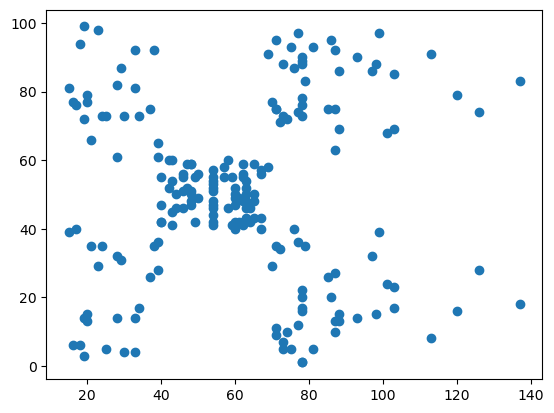

In [9]:
plt.scatter(data['Annual Income (k$)'],data['Spending Score (1-100)'])
plt.show()

**K-Means**

In [ ]:
# We need to decide the number of clusters
# Elbow method
# Within sum of squares
# we randomly gives 10 clusters, for each cluster will calculate
# within sum of squares

**Elbow Method**

- Sum of square with in the clusters (SSW)
    - Variance in side the clusters
    - Variance in side the clusters should be low 
- Sum of square between the clusters (SSB)
    - Variacne between the clusters
    - Variacne between the clusters should be max
    - Then only we can sure that clusters apart from each other

Example:- 9000    5000    1000    900    850
           1        2       3     4       5

**First we check for one cluster to understand within sum of squares concept**

In [11]:
from sklearn.cluster import KMeans

In [12]:
### Jusyt applying one cluster
### Base model

In [14]:
Kmeans_1=KMeans(n_clusters=1,max_iter=300,random_state=1234)
Kmeans_1

# n_cluster = no of cluster to choose 
# max_oter = the distance calculations
# random state = picking a random observations

,n_clusters,1
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1234
,copy_x,True
,algorithm,'lloyd'


In [15]:
Kmeans_1.fit(X)

C:\Users\SIDDESH R M\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,1
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1234
,copy_x,True
,algorithm,'lloyd'


$Inertia$:

- measures how well a dataset was clustered by K-means.
- it is calculated by measuring the distance between each data point and it centroid, squaring this distance,
- and summing these squares across one cluster

In [16]:
Kmeans_1.inertia_

269981.28

In [19]:
Kmeans_1.cluster_centers_        # it will give mean

array([[60.56, 50.2 ]])

In [20]:
data['Annual Income (k$)'].mean(),data['Spending Score (1-100)'].mean()

(np.float64(60.56), np.float64(50.2))

In [26]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


**Try to identify optimal clusters using elbow method**

In [35]:
import warnings

warnings.filterwarnings('ignore')

wss=[]

for i in range(1,10):
    
    Kmeans=KMeans(n_clusters=i,max_iter=300,random_state=1234)
    Kmeans.fit(X)
    wss.append(round(Kmeans.inertia_,2))

In [36]:
wss          # useless cluster == gap is reduced.  u can see below outputby going down gap is reduced

[269981.28,
 185140.02,
 106348.37,
 73880.64,
 44448.46,
 37233.81,
 30241.34,
 29474.65,
 23977.39]

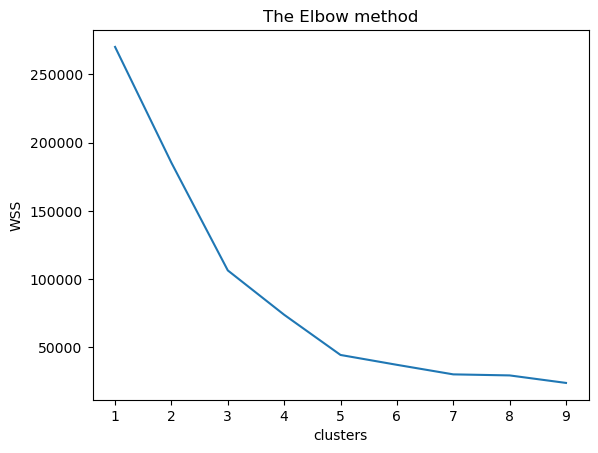

In [37]:
plt.plot(range(1,10),wss)
plt.title("The Elbow method")
plt.xlabel("clusters")
plt.ylabel("WSS")
plt.show()

**Using elbow method we decided number of clusters are 5**

In [41]:
len(X)
X[:5]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]])

In [40]:
Kmeans=KMeans(n_clusters=5,max_iter=300,random_state=1234)
y_clusters=Kmeans.fit_predict(X)  # which data point belongs to which cluster
y_clusters


# Here 0 = cluster_1 and 4 = cluster_5
# Python index start with zero

array([0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 4,
       0, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 3, 1, 4, 1, 3, 1, 3, 1,
       4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [42]:
data['Cluster_group']=y_clusters

In [43]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,0
1,2,Male,21,15,81,2
2,3,Female,20,16,6,0
3,4,Female,23,16,77,2
4,5,Female,31,17,40,0


In [44]:
data['Cluster_group'].value_counts()

Cluster_group
4    81
1    39
3    35
0    23
2    22
Name: count, dtype: int64

In [89]:
cols=['Annual Income (k$)','Spending Score (1-100)']         # here for this both columns come under "Cluster groups"
data[data['Cluster_group']==0][cols]

,Annual Income (k$),Spending Score (1-100)
0,15,39
2,16,6
4,17,40
6,18,6
8,19,3
10,19,14
12,20,15
14,20,13
16,21,35
18,23,29


In [50]:
# Group the data points
cs_1=data[data['Cluster_group']==0].iloc[:,[3,4]]
cs_2=data[data['Cluster_group']==1].iloc[:,[3,4]]
cs_3=data[data['Cluster_group']==2].iloc[:,[3,4]]
cs_4=data[data['Cluster_group']==3].iloc[:,[3,4]]
cs_5=data[data['Cluster_group']==4].iloc[:,[3,4]]
d1={"Cluster-1":cs_1.mean(),
    "Cluster-2":cs_2.mean(),
    "Cluster-3":cs_3.mean(),
    "Cluster-4":cs_4.mean(),
    "Cluster-5":cs_5.mean(),}
pd.DataFrame(d1)

,Cluster-1,Cluster-2,Cluster-3,Cluster-4,Cluster-5
Annual Income (k$),26.304348,86.538462,25.727273,88.200000,55.296296
Spending Score (1-100),20.913043,82.128205,79.363636,17.114286,49.518519


- We read the data
- We selected specific columns
- We given randomly 10 clusters
- We calculated the inertia
- By using elbow method, we decide 5 clusters are enough
- We pass the 5 clusters to the K-means
- We pass the data(x) and the get cluster values for all observations
- We divide into 5 data frames w.r.t the clusters observations
- We calculated Average income and Average spending score of each cluster observation

(array([6., 0., 4., 2., 0., 0., 2., 3., 4., 2.]),
 array([ 3. ,  6.7, 10.4, 14.1, 17.8, 21.5, 25.2, 28.9, 32.6, 36.3, 40. ]),
 <BarContainer object of 10 artists>)

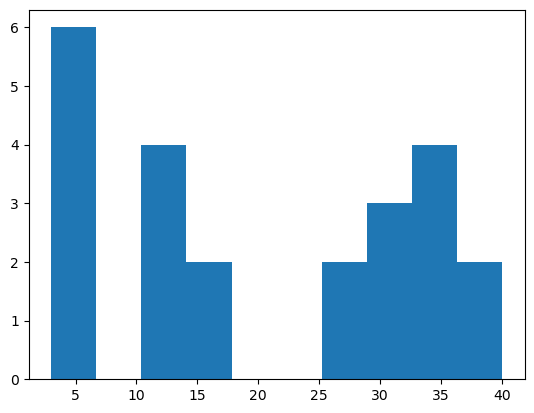

In [52]:
plt.hist(cs_1['Spending Score (1-100)'])

In [88]:
X

# 0 index columns = 15,15,16
# 1 index columns = 39,81,6

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [54]:
[y_clusters==0,0]       # 0 ,0  first row belongs to 0cluster
                        # scond row is belons t

[array([ True, False,  True, False,  True, False,  True, False,  True,
        False,  True, False,  True, False,  True, False,  True, False,
         True, False,  True, False,  True, False,  True, False,  True,
        False,  True, False,  True, False,  True, False,  True, False,
         True, False,  True, False,  True, False,  True, False,  True,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
      

In [92]:
print(X[y_clusters==0,0])     #  1 st Row data points , which are belongs to 0 cluster , means 0 cluster 0 col
print(X[y_clusters==1,0])    #  2 nd Row data points , which are belongs to 1 cluster , means 1 cluster o col
print(X[y_clusters==2,0])    #  
print(X[y_clusters==3,0])

print(X[y_clusters==0,1])   # 0 cluster 1 st row


[15 16 17 18 19 19 20 20 21 23 24 25 28 28 29 30 33 33 34 37 38 39 39]
[ 69  70  71  71  71  72  73  73  74  75  76  77  77  78  78  78  78  78
  78  79  81  85  86  87  87  87  88  88  93  97  98  99 101 103 103 113
 120 126 137]
[15 16 17 18 19 19 20 20 21 23 24 25 28 28 29 30 33 33 34 37 38 39]
[ 70  71  71  73  73  74  75  77  77  78  78  78  78  78  78  79  81  85
  86  87  87  87  88  88  93  97  98  99 101 103 103 113 120 126 137]
[39  6 40  6  3 14 15 13 35 29 35  5 14 32 31  4  4 14 17 26 35 36 28]


In [ ]:
# for understanding

data[data['Cluster_group']==0][cols]     # here for this both ['Annual Income (k$)','Spending Score (1-100)'] columns come under "Cluster groups"
data[data['Cluster_group']==0,0]  # 0 index == 'Annual Income (k$)'
data[data['Cluster_group']==0,1]  # 1 index == 'Spending Score (1-100)'

In [91]:
data.tail(60)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
140,141,Female,57,75,5,3
141,142,Male,32,75,93,1
142,143,Female,28,76,40,4
143,144,Female,32,76,87,1
144,145,Male,25,77,12,3
145,146,Male,28,77,97,1
146,147,Male,48,77,36,3
147,148,Female,32,77,74,1
148,149,Female,34,78,22,3
149,150,Male,34,78,90,1


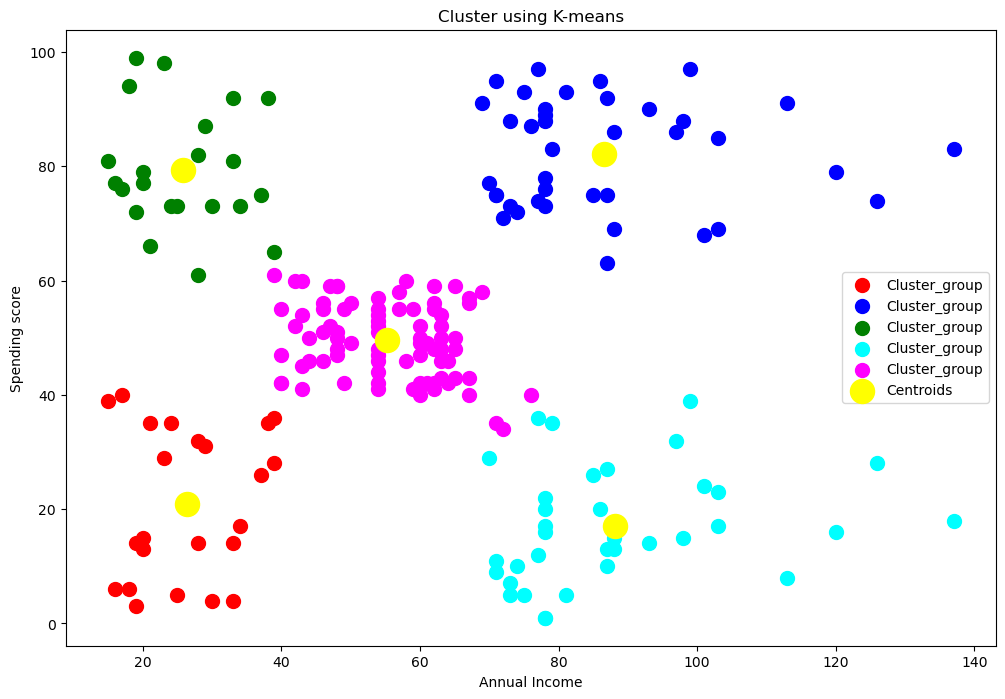

In [94]:
# Visualize the clusters
# We are applying scatter plot betwee income and spending score w.rt to cluster
plt.figure(figsize=(12,8))
plt.scatter(X[y_clusters==0,0],X[y_clusters==0,1],s=100,c='red',label="Cluster_group")
plt.scatter(X[y_clusters==1,0],X[y_clusters==1,1],s=100,c='blue',label="Cluster_group")
plt.scatter(X[y_clusters==2,0],X[y_clusters==2,1],s=100,c='green',label="Cluster_group")
plt.scatter(X[y_clusters==3,0],X[y_clusters==3,1],s=100,c='cyan',label="Cluster_group")
plt.scatter(X[y_clusters==4,0],X[y_clusters==4,1],s=100,c='magenta',label="Cluster_group")
plt.scatter(Kmeans.cluster_centers_[:,0],Kmeans.cluster_centers_[:,1],s=300,c='yellow',label='Centroids')
plt.title("Cluster using K-means")
plt.xlabel("Annual Income")
plt.ylabel("Spending score")
plt.legend()
plt.show()

# Where s will give the size of the centroid

$Hierarchical$  $Cluster$

In [98]:
import scipy.cluster.hierarchy as sch                         # 90 th class

**Linkage functions**

- Every observations consider as one cluster
- Based on symmetry matrix we from the groups
- Linkage functions
    - Simple linkage : Less distance that means more relation
    - Complete linkage : Max distance that means less relation
    - Average Ward Method

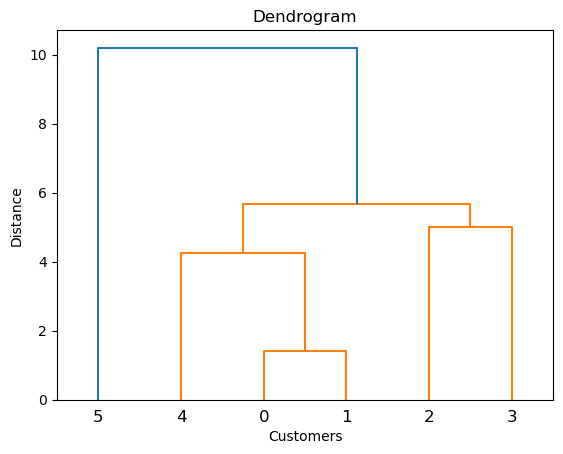

In [108]:
val=[[2,5],[3,6],[7,10],[12,10],[6,3],[10,20]]
sch.linkage(val)

dendogram=sch.dendrogram(sch.linkage(val,method='single'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [96]:
sch.linkage(X,method='single')

array([[ 48.        ,  49.        ,   0.        ,   2.        ],
       [ 65.        ,  68.        ,   0.        ,   2.        ],
       [156.        , 158.        ,   0.        ,   2.        ],
       [129.        , 131.        ,   0.        ,   2.        ],
       [ 67.        ,  69.        ,   1.        ,   2.        ],
       [ 64.        ,  66.        ,   1.        ,   2.        ],
       [ 60.        ,  61.        ,   1.        ,   2.        ],
       [ 63.        , 201.        ,   1.        ,   3.        ],
       [ 51.        ,  53.        ,   1.        ,   2.        ],
       [ 74.        ,  77.        ,   1.        ,   2.        ],
       [ 85.        , 209.        ,   1.        ,   3.        ],
       [ 79.        ,  82.        ,   1.        ,   2.        ],
       [ 78.        ,  80.        ,   1.        ,   2.        ],
       [ 76.        , 212.        ,   1.        ,   3.        ],
       [ 75.        , 213.        ,   1.        ,   4.        ],
       [ 81.        , 214

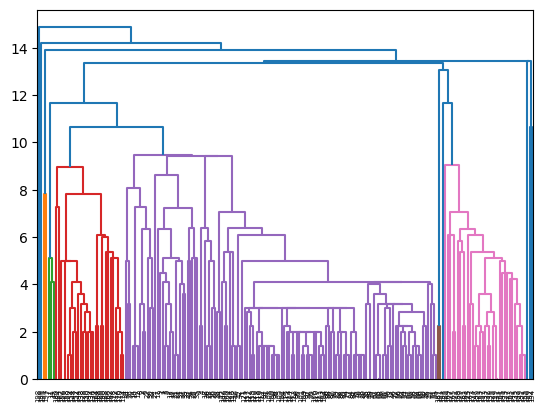

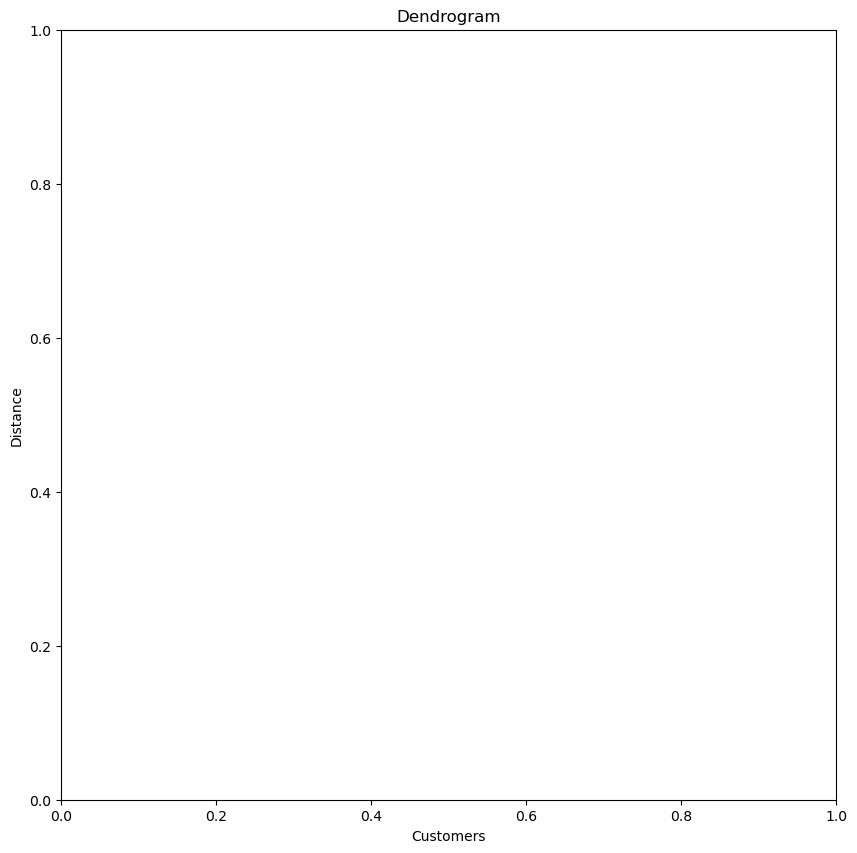

In [112]:
# Dendogram Using Single
dendogram=sch.dendrogram(sch.linkage(X,method='single'))
plt.figure(figsize=(10,10))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

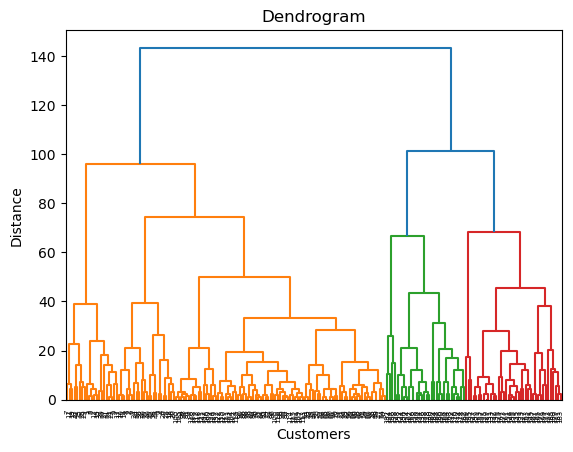

In [113]:
dendogram=sch.dendrogram(sch.linkage(X,method='complete'))

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

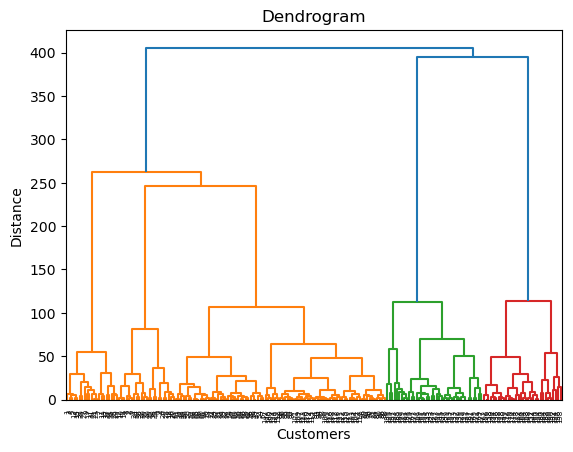

In [114]:
dendogram=sch.dendrogram(sch.linkage(X,method='ward'))

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

$Method-2$:

In [117]:
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
y_hc=hc.fit_predict(X)
y_hc

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

In [119]:
y_clusters       # see the observations

array([0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 4,
       0, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 3, 1, 4, 1, 3, 1, 3, 1,
       4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

in kmeans somne things belongs to 0 clusters, same thing in "hc" belongs 4 th cluster 

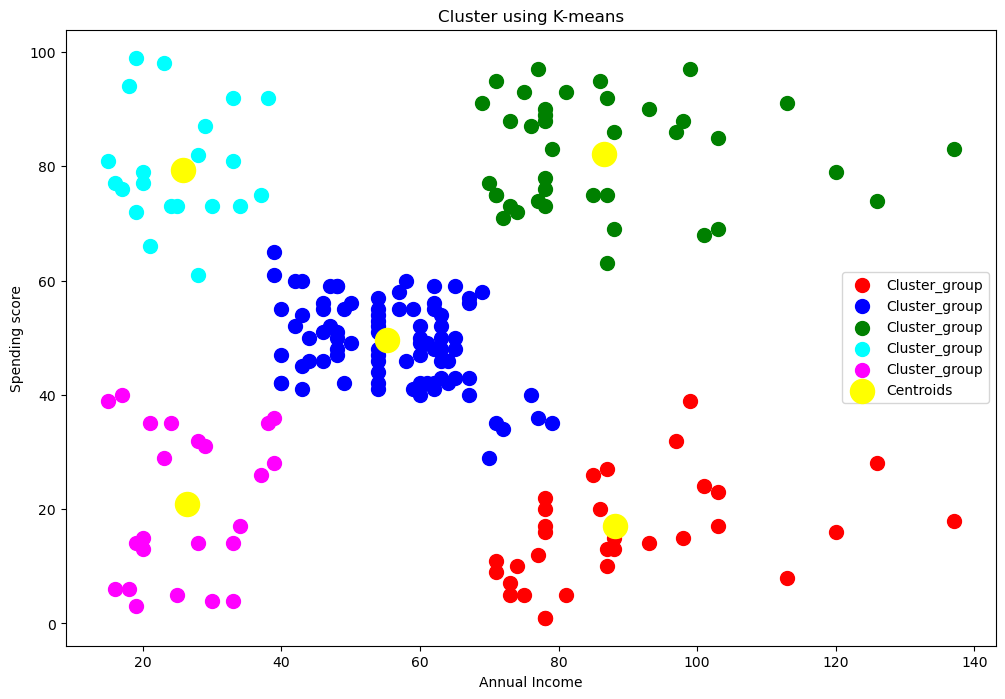

In [120]:
# Visualize the clusters
# We are applying scatter plot betwee income and spending score w.rt to clusters
plt.figure(figsize=(12,8))
plt.scatter(X[y_hc==0,0],X[y_hc==0,1],s=100,c='red',label="Cluster_group")
plt.scatter(X[y_hc==1,0],X[y_hc==1,1],s=100,c='blue',label="Cluster_group")
plt.scatter(X[y_hc==2,0],X[y_hc==2,1],s=100,c='green',label="Cluster_group")
plt.scatter(X[y_hc==3,0],X[y_hc==3,1],s=100,c='cyan',label="Cluster_group")
plt.scatter(X[y_hc==4,0],X[y_hc==4,1],s=100,c='magenta',label="Cluster_group")
plt.scatter(Kmeans.cluster_centers_[:,0],Kmeans.cluster_centers_[:,1],s=300,c='yellow',label='Centroids')
plt.title("Cluster using K-means")
plt.xlabel("Annual Income")
plt.ylabel("Spending score")
plt.legend()
plt.show()